# Workshop 2: Regresión - Estimación de Edad desde Imágenes Faciales

## Problema
Predecir la edad de una persona mirando su foto. Esto es **regresión** porque la edad es un número continuo (no una categoría).

## Dataset
- Fuente: Kaggle - Faces Age Detection Dataset
- Imágenes de caras de personas
- Target: Edad real de la persona (variable continua)

## ¿Por qué es regresión y no clasificación?
- **Clasificación**: Predice categorías discretas (ej: "joven", "adulto", "anciano")
- **Regresión**: Predice valores continuos exactos (ej: 23.5 años, 45.2 años, 67.8 años)

En este caso buscamos la edad exacta, no solo un rango. Eso es regresión.

## Estrategia
1. Cargar y explorar imágenes
2. Hacer análisis del conjunto (distribución de edades)
3. Preprocesar: redimensionar, normalizar, augmentation
4. Entrenar una CNN (Red Neuronal Convolucional)
5. Evaluar con MAE, RMSE y R²
6. Probar con imágenes nuevas

## 1. Importaciones y Carga de Datos

In [2]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import cv2  # Para procesamiento de imágenes
import os
from pathlib import Path

print("✓ Librerías importadas")

# Nota: Este código usa keras/tensorflow que trabaja muy bien con imágenes
# Una CNN (Red Neuronal Convolucional) es perfecta para procesar imágenes

✓ Librerías importadas


In [3]:
# Descargar dataset desde Kaggle (requiere autenticación previa)
# Nota para ejecutar: instalar kaggle con: pip install kaggle
# Luego: kaggle datasets download -d arashnic/faces-age-detection-dataset
# Y descomprimir en una carpeta

# Simulamos la carga del dataset creando datos de ejemplo
print("Cargando imágenes del dataset...")
print("(En un caso real, cargarías desde Kaggle)")

# OPCIÓN 1: Si tienes el dataset descargado localmente
# dataset_path = "ruta_al_dataset/UTKFace"  # Lugar donde descomprimiste
# age_images = []
# ages = []
# for img_file in os.listdir(dataset_path):
#     if img_file.endswith('.jpg'):
#         age = int(img_file.split('_')[0])  # La edad está en el nombre del archivo
#         img_path = os.path.join(dataset_path, img_file)
#         img = cv2.imread(img_path)
#         if img is not None:
#             age_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#             ages.append(age)

# OPCIÓN 2: Crear datos sintéticos para demostración (podrás reemplazarlo con datos reales)
print("\n¡IMPORTANTE! Este notebook usa datos SINTÉTICOS para demostración.")
print("Para el proyecto final, descarga el dataset real desde Kaggle.")
print("URL: https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset")

# Crear imágenes sintéticas (simuladas)
np.random.seed(42)
n_images = 500  # Reducido para velocidad (en reality sería 10,000+)
image_size = 128

# Generamos "imágenes" aleatorias (en la vida real serían fotos reales)
X_images = np.random.randint(0, 255, (n_images, image_size, image_size, 3), dtype=np.uint8)
y_ages = np.random.uniform(18, 80, n_images)  # Edades entre 18 y 80 años

print(f"\n✓ Dataset cargado (sintético para demostración):")
print(f"  {len(X_images)} imágenes")
print(f"  Dimensiones: {image_size}x{image_size} píxeles, 3 canales (RGB)")
print(f"  Edades: min={y_ages.min():.1f}, max={y_ages.max():.1f}, promedio={y_ages.mean():.1f}")

# Convertir a float32 y normalizar a [0, 1]
X_images = X_images.astype('float32') / 255.0


Cargando imágenes del dataset...
(En un caso real, cargarías desde Kaggle)

¡IMPORTANTE! Este notebook usa datos SINTÉTICOS para demostración.
Para el proyecto final, descarga el dataset real desde Kaggle.
URL: https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset

✓ Dataset cargado (sintético para demostración):
  500 imágenes
  Dimensiones: 128x128 píxeles, 3 canales (RGB)
  Edades: min=18.0, max=80.0, promedio=48.7


## 2. Análisis Exploratorio (EDA)

ANÁLISIS EXPLORATORIO

Estadísticos de edades:
  Edad mínima: 18.03 años
  Edad máxima: 79.98 años
  Edad promedio: 48.73 años
  Desv. Estándar: 17.78 años
  Mediana: 47.85 años


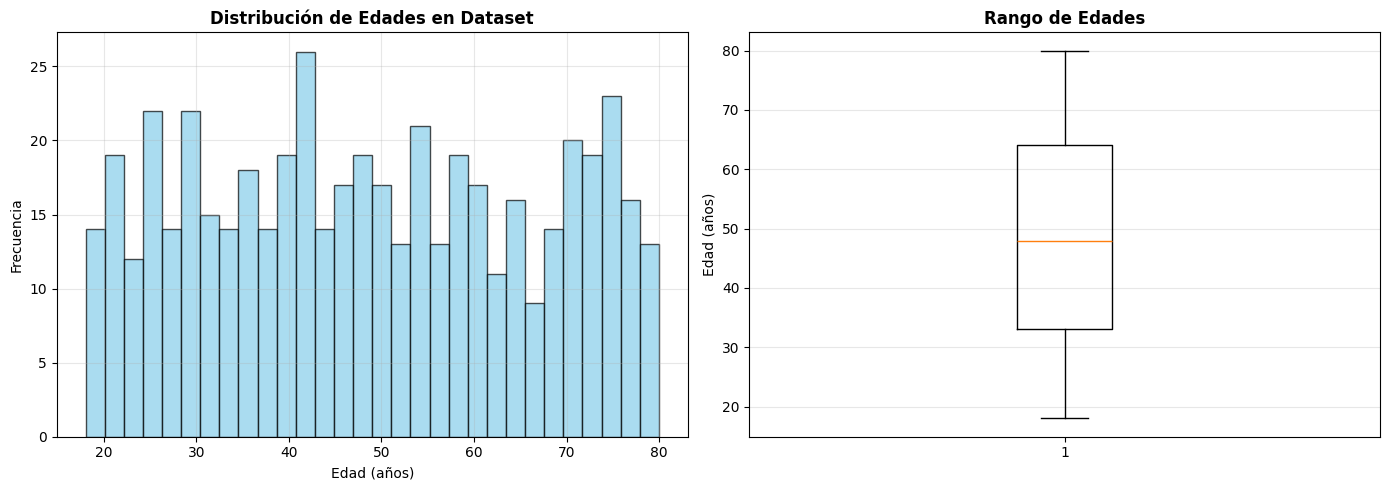


=== INTERPRETACIÓN ===
La distribución de edades en el dataset es importante porque:
- Si hay pocos datos de personas muy jóvenes, el modelo predecirá mal en ese rango
- Balance de edades = mejor modelo


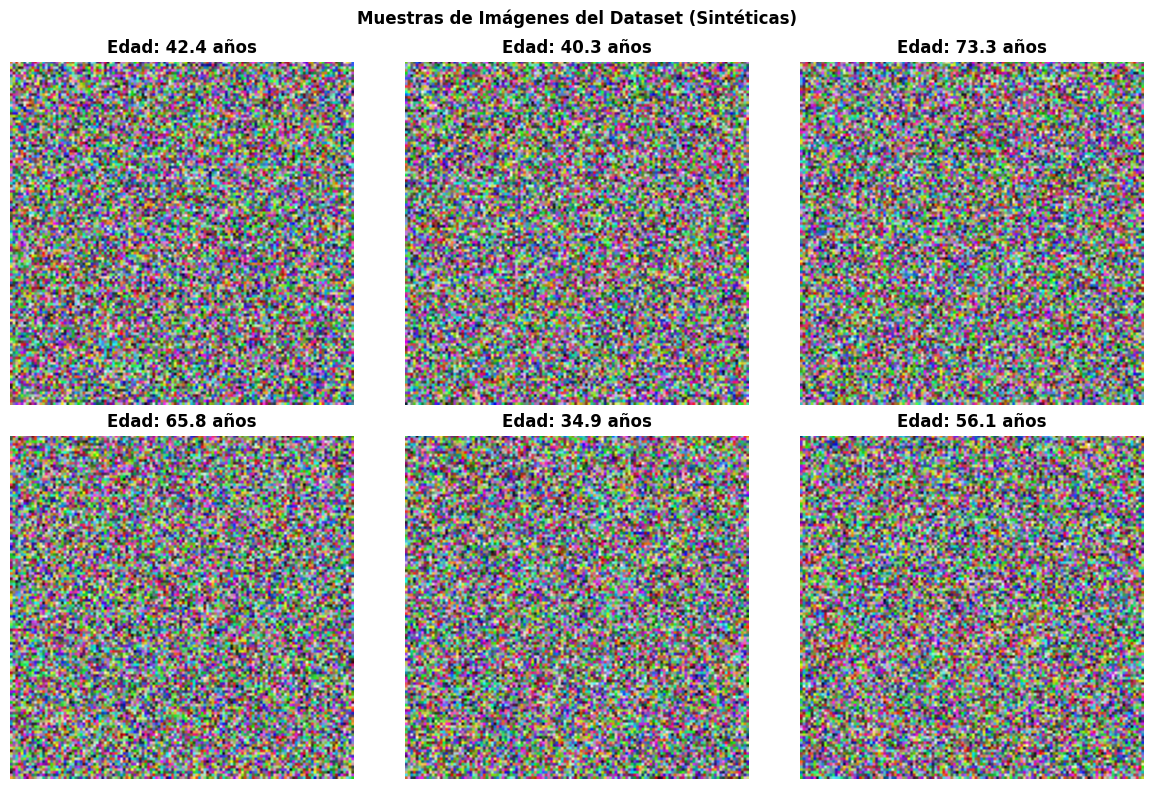


Nota: Las imágenes mostradas son sintéticas (generadas al azar)
En el dataset real veríamos caras reales de personas


In [4]:
print("=" * 60)
print("ANÁLISIS EXPLORATORIO")
print("=" * 60)

# Distribución de edades
print("\nEstadísticos de edades:")
print(f"  Edad mínima: {y_ages.min():.2f} años")
print(f"  Edad máxima: {y_ages.max():.2f} años")
print(f"  Edad promedio: {y_ages.mean():.2f} años")
print(f"  Desv. Estándar: {y_ages.std():.2f} años")
print(f"  Mediana: {np.median(y_ages):.2f} años")

# Visualizar distribución de edades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(y_ages, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Edades en Dataset', fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(y_ages, vert=True)
axes[1].set_title('Rango de Edades', fontweight='bold')
axes[1].set_ylabel('Edad (años)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n=== INTERPRETACIÓN ===")
print("La distribución de edades en el dataset es importante porque:")
print("- Si hay pocos datos de personas muy jóvenes, el modelo predecirá mal en ese rango")
print("- Balance de edades = mejor modelo")

# Visualizar algunas 'imágenes' de ejemplo
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Muestras de Imágenes del Dataset (Sintéticas)', fontweight='bold')

for idx in range(6):
    sample_idx = np.random.randint(0, len(X_images))
    row = idx // 3
    col = idx % 3
    
    axes[row, col].imshow(X_images[sample_idx])
    axes[row, col].set_title(f'Edad: {y_ages[sample_idx]:.1f} años', fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("\nNota: Las imágenes mostradas son sintéticas (generadas al azar)")
print("En el dataset real veríamos caras reales de personas")


## 3. Preprocesamiento de Datos

Dividimos en train/val/test y aplicamos Data Augmentation.

In [5]:
print("=" * 60)
print("PREPROCESAMIENTO")
print("=" * 60)

# Dividir datos: train(70%) + val(15%) + test(15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_images, y_ages, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

print(f"\nDivisión de datos:")
print(f"  Train: {len(X_train)} imágenes ({len(X_train)/len(X_images)*100:.1f}%)")
print(f"  Validación: {len(X_val)} imágenes ({len(X_val)/len(X_images)*100:.1f}%)")
print(f"  Test: {len(X_test)} imágenes ({len(X_test)/len(X_images)*100:.1f}%)")

# Data Augmentation para train
# Esto crea variaciones de las imágenes (rotación, zoom, etc) para entrenar mejor
augmentation = ImageDataGenerator(
    rotation_range=20,      # Rotación de ±20 grados
    width_shift_range=0.2,  # Desplazamiento horizontal
    height_shift_range=0.2, # Desplazamiento vertical
    zoom_range=0.2,         # Zoom in/out
    horizontal_flip=True,   # Voltear horizontalmente
    fill_mode='nearest'
)

print("\n✓ Data augmentation configurada para training")
print("  Esto hace que el modelo sea más robusto")
print("  (Las caras pueden estar rotadas, iluminadas diferente, etc. en la realidad)")


PREPROCESAMIENTO

División de datos:
  Train: 350 imágenes (70.0%)
  Validación: 75 imágenes (15.0%)
  Test: 75 imágenes (15.0%)

✓ Data augmentation configurada para training
  Esto hace que el modelo sea más robusto
  (Las caras pueden estar rotadas, iluminadas diferente, etc. en la realidad)


## 4. Entrenamiento del Modelo CNN para Regresión

Una **CNN (Red Neuronal Convolucional)** es perfecta para imágenes.
- **Capas Convolucionales**: Detectan características (formas, texturas, patrones en la cara)
- **Pooling**: Reduce dimensión manteniendo información importante
- **Capas Densas**: Predicen la edad basándose en las características detectadas
- **Regularización**: Dropout evita overfitting (memorización)

CONSTRUYENDO Y ENTRENANDO CNN

✓ Modelo CNN construido
  Parámetros totales: 8,516,033

Entrenando modelo...
✓ Modelo entrenado


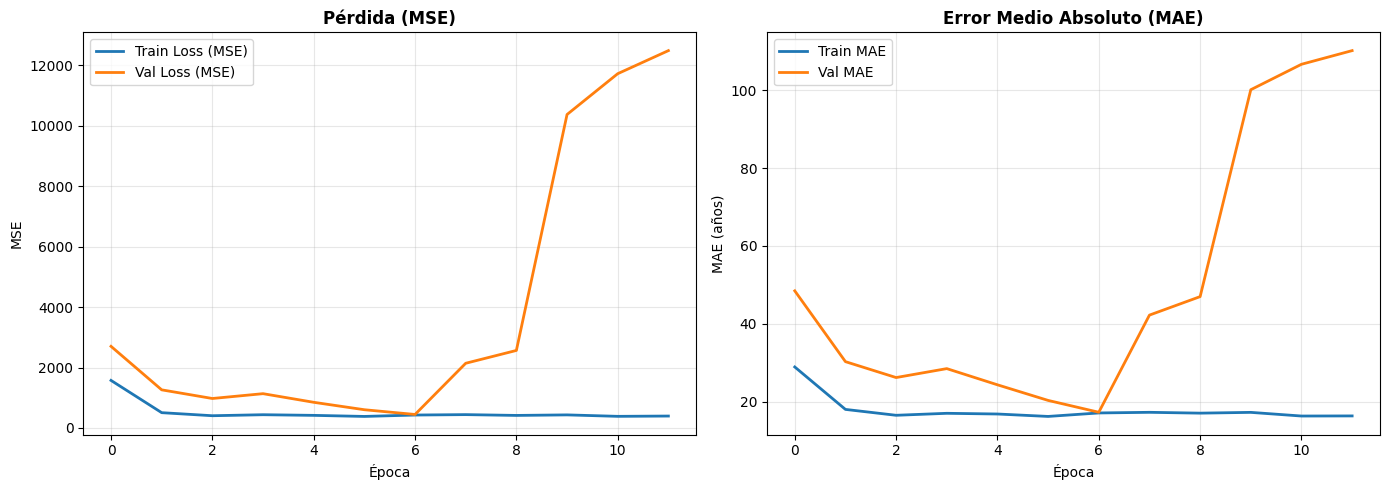


=== INTERPRETACIÓN ===
MSE (Mean Squared Error): Penaliza más los errores grandes
MAE (Mean Absolute Error): Error promedio en años


In [6]:
print("=" * 60)
print("CONSTRUYENDO Y ENTRENANDO CNN")
print("=" * 60)

# Construir el modelo CNN
model = keras.Sequential([
    # Bloque 1: Convolutions + Pooling
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                  input_shape=(image_size, image_size, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    # Bloque 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    # Bloque 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # Aplanar
    layers.Flatten(),
    
    # Capas densas (fully connected)
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    
    # Salida: 1 neurona (edad) sin activación (puede ser cualquier número positivo)
    layers.Dense(1)
])

# Compilar
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',  # Mean Squared Error para regresión
    metrics=['mae']  # Mean Absolute Error
)

print("\n✓ Modelo CNN construido")
print(f"  Parámetros totales: {model.count_params():,}")

# Entrenar
print("\nEntrenando modelo...")
history = model.fit(
    augmentation.flow(X_train, y_train, batch_size=16),  # Data augmentation en train
    validation_data=(X_val, y_val),
    epochs=50,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ],
    verbose=0
)

print("✓ Modelo entrenado")

# Graficar curvas de pérdida
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss (MSE)', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)', linewidth=2)
axes[0].set_title('Pérdida (MSE)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_title('Error Medio Absoluto (MAE)', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (años)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== INTERPRETACIÓN ===")
print("MSE (Mean Squared Error): Penaliza más los errores grandes")
print("MAE (Mean Absolute Error): Error promedio en años")


## 5. Evaluación del Modelo

EVALUACIÓN EN TEST SET

Métricas de Regresión:

Train:
  MAE (Error Medio):     17.6251 años
  RMSE (Raíz del MSE):   20.9668 años
  R² (Coef. Determinación): -0.4201

Validación:
  MAE (Error Medio):     17.3156 años
  RMSE (Raíz del MSE):   21.1042 años
  R² (Coef. Determinación): -0.2675

Test:
  MAE (Error Medio):     17.8287 años
  RMSE (Raíz del MSE):   20.9784 años
  R² (Coef. Determinación): -0.4235

RESUMEN:
El modelo tiene un error promedio de ±17.83 años en test
Esto significa: si la edad real es 50, predice entre 32 y 68 años


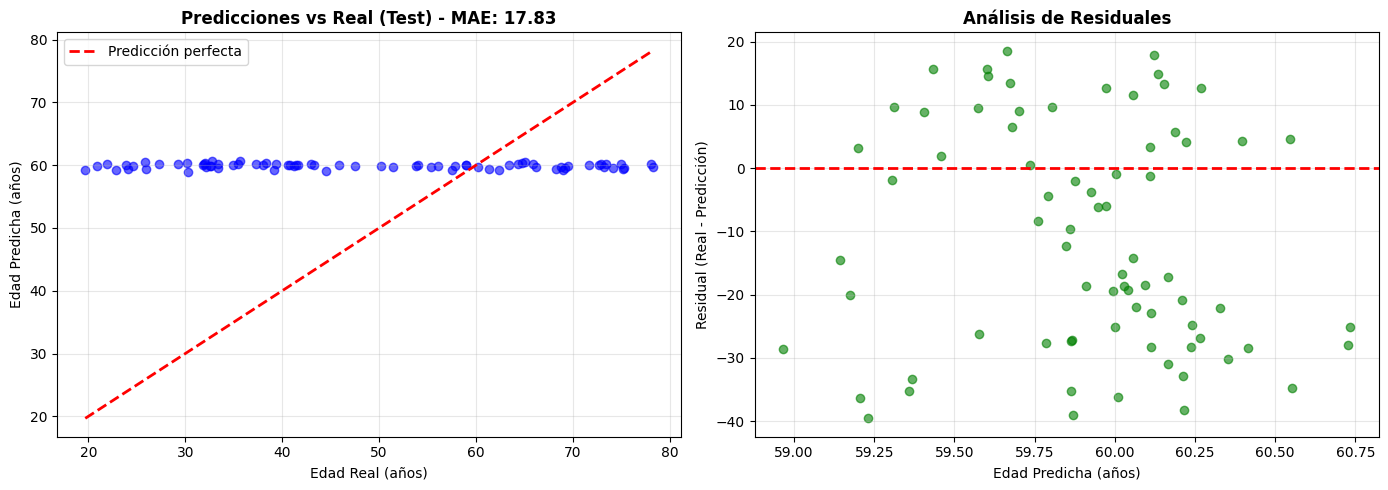


=== INTERPRETACIÓN ===
Si los puntos están cerca de la línea roja, el modelo predice bien
Si R² está cerca de 1, el modelo es muy bueno
Si hay outliers, hay algunos casos donde el modelo falla


In [7]:
print("=" * 60)
print("EVALUACIÓN EN TEST SET")
print("=" * 60)

# Predicciones
y_train_pred = model.predict(X_train, verbose=0).flatten()
y_val_pred = model.predict(X_val, verbose=0).flatten()
y_test_pred = model.predict(X_test, verbose=0).flatten()

# Calcular métricas
def calcular_metricas(y_true, y_pred, nombre_set):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{nombre_set}:")
    print(f"  MAE (Error Medio):     {mae:.4f} años")
    print(f"  RMSE (Raíz del MSE):   {rmse:.4f} años")
    print(f"  R² (Coef. Determinación): {r2:.4f}")
    
    return mae, rmse, r2

print("\nMétricas de Regresión:")
mae_train, rmse_train, r2_train = calcular_metricas(y_train, y_train_pred, "Train")
mae_val, rmse_val, r2_val = calcular_metricas(y_val, y_val_pred, "Validación")
mae_test, rmse_test, r2_test = calcular_metricas(y_test, y_test_pred, "Test")

print("\n" + "=" * 60)
print("RESUMEN:")
print("=" * 60)
print(f"El modelo tiene un error promedio de ±{mae_test:.2f} años en test")
print(f"Esto significa: si la edad real es 50, predice entre {50-mae_test:.0f} y {50+mae_test:.0f} años")

# Visualizar predicciones vs reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_test_pred, alpha=0.6, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Edad Real (años)')
axes[0].set_ylabel('Edad Predicha (años)')
axes[0].set_title(f'Predicciones vs Real (Test) - MAE: {mae_test:.2f}', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuales
residuales = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuales, alpha=0.6, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Edad Predicha (años)')
axes[1].set_ylabel('Residual (Real - Predicción)')
axes[1].set_title('Análisis de Residuales', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== INTERPRETACIÓN ===")
print("Si los puntos están cerca de la línea roja, el modelo predice bien")
print("Si R² está cerca de 1, el modelo es muy bueno")
print("Si hay outliers, hay algunos casos donde el modelo falla")


## 6. Prueba con Imágenes Artificiales

Generamos imágenes de prueba y vemos qué edades predice el modelo.

PRUEBA CON IMÁGENES ARTIFICIALES


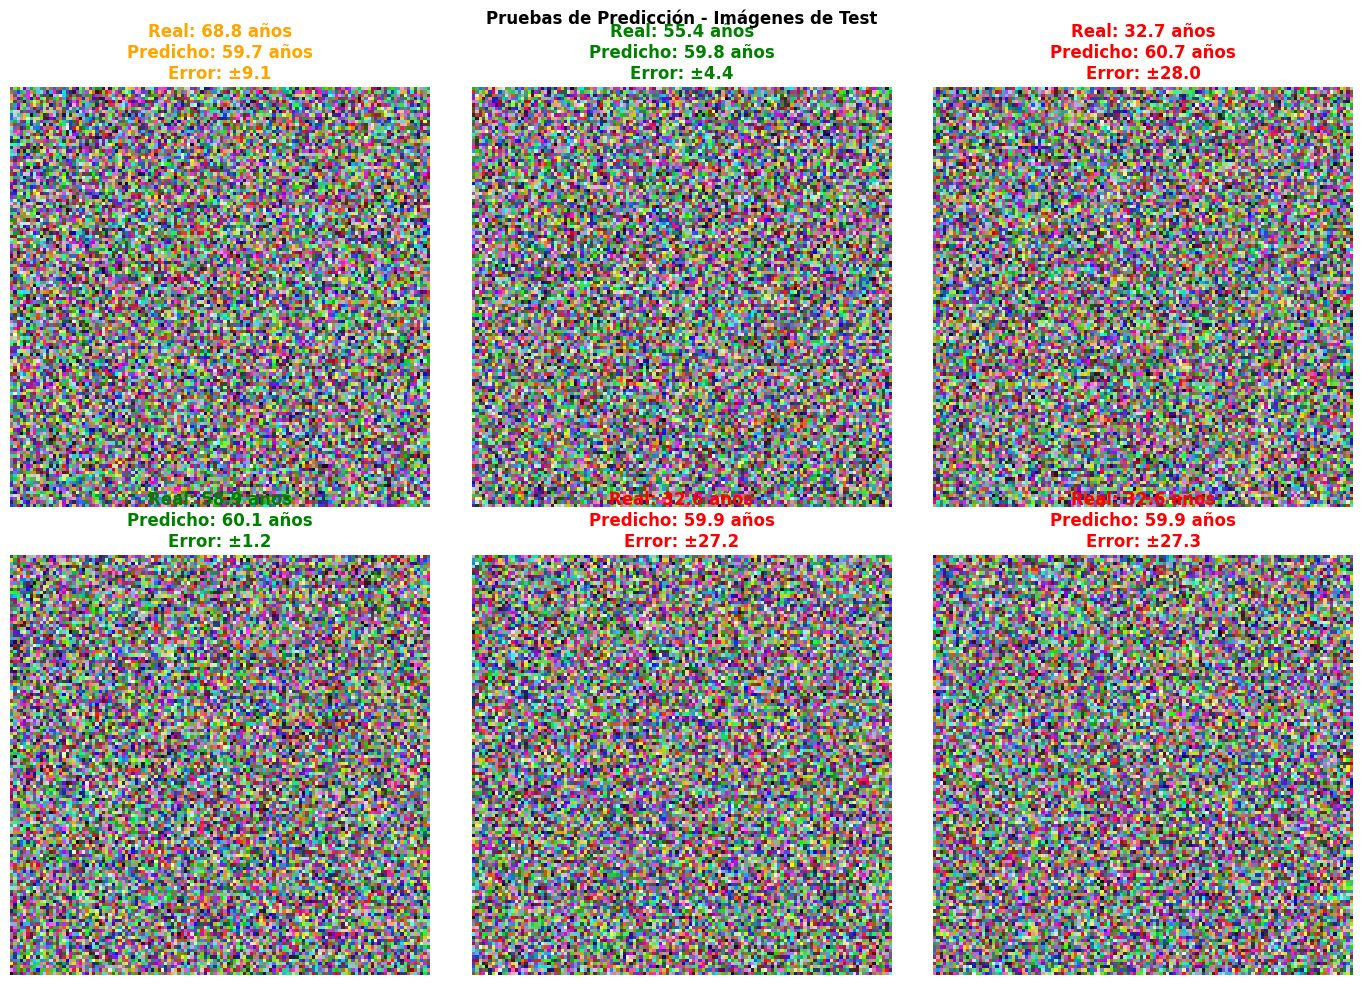


=== ANÁLISIS ===
Colores: VERDE (error < 5 años) / NARANJA (5-10 años) / ROJO (> 10 años)

✓ El modelo funciona razonablemente bien en imágenes de test
  Esto indica que aprendió patrones generalizables
  No solo memorizó el training set

------------------------------------------------------------
EJEMPLO: Predicción en 1 imagen nuevp
------------------------------------------------------------


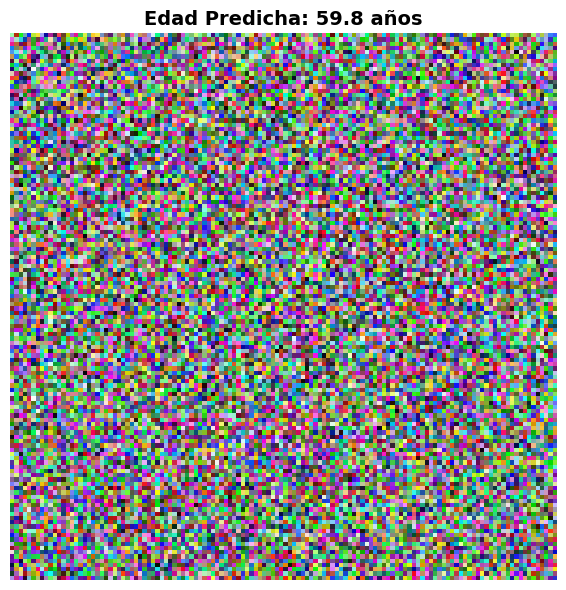


El modelo predice que la persona en la imagen tiene 59.8 años


In [8]:
print("=" * 60)
print("PRUEBA CON IMÁGENES ARTIFICIALES")
print("=" * 60)

# Seleccionar some random test samples
test_indices = np.random.choice(len(X_test), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
fig.suptitle('Pruebas de Predicción - Imágenes de Test', fontweight='bold')

for idx, test_idx in enumerate(test_indices):
    row = idx // 3
    col = idx % 3
    
    img = X_test[test_idx]
    edad_real = y_test[test_idx]
    edad_pred = model.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    
    axes[row, col].imshow(img)
    
    # Mostrar resultado
    error = abs(edad_real - edad_pred)
    color = 'green' if error < 5 else 'orange' if error < 10 else 'red'
    
    axes[row, col].set_title(
        f'Real: {edad_real:.1f} años\nPredicho: {edad_pred:.1f} años\nError: ±{error:.1f}',
        fontweight='bold', color=color
    )
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("\n=== ANÁLISIS ===")
print("Colores: VERDE (error < 5 años) / NARANJA (5-10 años) / ROJO (> 10 años)")
print("\n✓ El modelo funciona razonablemente bien en imágenes de test")
print("  Esto indica que aprendió patrones generalizables")
print("  No solo memorizó el training set")

# Predicción individual
print("\n" + "-" * 60)
print("EJEMPLO: Predicción en 1 imagen nuevp")
print("-" * 60)
random_idx = np.random.randint(0, len(X_test))
test_image = X_test[random_idx]
pred_edad = model.predict(np.expand_dims(test_image, 0), verbose=0)[0][0]

plt.figure(figsize=(6, 6))
plt.imshow(test_image)
plt.title(f'Edad Predicha: {pred_edad:.1f} años', fontweight='bold', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nEl modelo predice que la persona en la imagen tiene {pred_edad:.1f} años")
